# Gradient Descent Optimization
Converting Julia notebook to Python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm, pinv
from scipy.stats import norm as scipy_norm
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Create data set
True model: $y=f(z)=\sin(z)$ for $z\in[-\pi,\pi]$.

Data: $N=10$ equidistant measurements $y$ plus random Gaussian noise.

In [2]:
# number of samples
N = 10

# input values, equally spaced in the interval [-pi, pi]
z = np.linspace(-np.pi, np.pi, N)

# output values
y = np.sin(z) + 0.3 * np.random.randn(N)

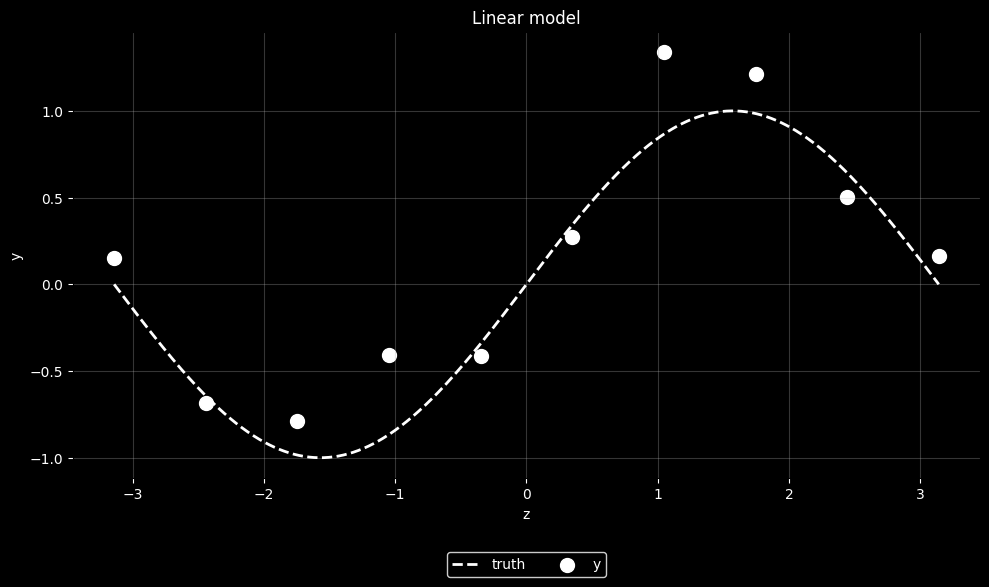

In [3]:
# Plotting the results

# array for creating analytical plot lines
N_grid = 1000
z_grid = np.linspace(-np.pi, np.pi, N_grid)
y_grid = np.sin(z_grid)

# plot
plt.figure(figsize=(10, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
ax.grid(True, alpha=0.3)
ax.plot(z_grid, y_grid, 'w--', linewidth=2, label=r'truth')
ax.scatter(z, y, color='white', s=100, label=r'y')
ax.set_xlabel('z', color='white')
ax.set_ylabel('y', color='white')
ax.set_title('Linear model', color='white')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, 
         facecolor='black', edgecolor='white', labelcolor='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

# Comparison against the closed-form solution

Now let's train a polynomial model of degree $q-1$:
$$ h(z,w) = w_0 + w_1 z + \ldots + w_{q-1} z^{q-1}. $$
To this end, we use the mean squared error as our loss function:
$$L(w) = \frac{1}{N}\sum_{i=1}^N \|y_i - h(z_i,w)\|_2^2 $$

Creating the data matrices
$$ Z = \begin{bmatrix} 1 & z_1 & z_1^2 & \ldots & z_1^{q-1} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & z_N & z_N^2 & \ldots & z_N^{q-1} \end{bmatrix} \quad \text{and} \quad Y = \begin{bmatrix} y_1 \\ \vdots \\ y_N \end{bmatrix} $$
and using the mean squared loss $\|Y-Zw\|_F^2$, we find the closed-form solution
$$w = Z^\dagger Y.$$
$\hat{y} = \sum_{i=0}^{q-1} w_i z^i$ from the hypothesis function

In [4]:
# data matrix creation
def createZ(z, q):
    """
    Create polynomial data matrix of degree q-1
    """
    N = len(z)
    Z = np.zeros((N, q))
    
    for i in range(q):
        Z[:, i] = z ** i
    
    return Z

# Train the model using pseudo-inverse
def train_model(Z, y):
    """
    Train model using pseudo-inverse (least squares)
    """
    w = pinv(Z) @ y
    return w

# Model evaluation
def h(z, w):
    """
    Evaluate polynomial model h(z, w)
    It generates the predicted output y for input z and weights w
    """
    N = len(z)
    q = len(w)
    y = np.zeros(N)
    
    for i in range(q):
        y += w[i] * (z ** i) #vectorization of the polynomial evaluation
    
    return y

In [5]:
# let's use a polynomial of degree 3
q = 4

# create data matrix
Z = createZ(z, q)

# train model using least squares regression and get the weights
w_pinv = train_model(Z, y)

# evaluate model on the fine grid and get the predicted output
y_pinv = h(z_grid, w_pinv)

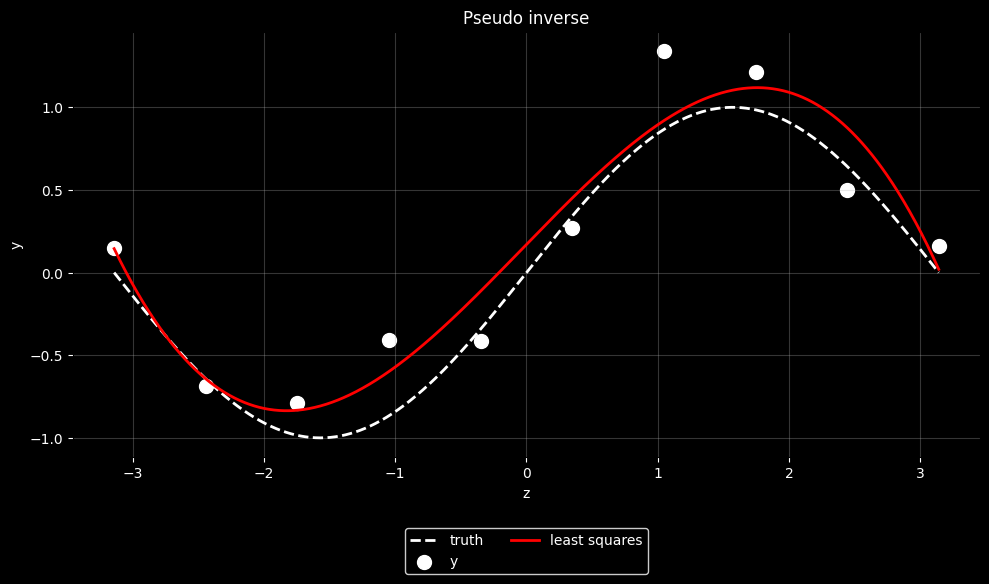

In [6]:
# Plotting the results
plt.figure(figsize=(10, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
ax.grid(True, alpha=0.3)
ax.plot(z_grid, y_grid, 'w--', linewidth=2, label=r'truth')
ax.scatter(z, y, color='white', s=100, label=r'y')
ax.plot(z_grid, y_pinv, 'r-', linewidth=2, label=r'least squares')
ax.set_xlabel('z', color='white')
ax.set_ylabel('y', color='white')
ax.set_title('Pseudo inverse', color='white')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2,
         facecolor='black', edgecolor='white', labelcolor='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

# Gradient descent with steepest descend direction and fixed step sizes

Now let's use gradient descent on the loss function $L(w)$.

The gradient of an individual sample $\ell$ w.r.t. a single coefficient $w_j$ is:
$$ \frac{\partial \ell(w)}{\partial w_j} = -2 (y_i - h(z_i, w)) z^j, $$
where $z^j$ is located in column $j+1$ of the data matrix $Z$. (Entry $i$ for sample $i$.)

The entire gradient is thus
$$ \nabla L(w) = -\frac{2}{N} Z^\top (y - Zw). $$

In [7]:
# Loss function
def L(w, Z, y):
    N = len(y)
    return (1/N) * norm(y - Z @ w, 2) ** 2

# Gradient of loss function
def dL(w, Z, y):
    N = len(y)
    return (2/N) * Z.T @ (Z @ w - y)

In [8]:
# initial guess w0
w0 = np.zeros(q)

# learning rate / step size
eta = 0.001

# iterative scheme
i_max = 1000
w_all = np.zeros((q, i_max))
L_all = np.zeros(i_max)

w_all[:, 0] = w0
L_all[0] = L(w0, Z, y) #loss function for all data points for the initial guess w0

for i in range(i_max - 1):
    # gradient step
    w_all[:, i + 1] = w_all[:, i] - eta * dL(w_all[:, i], Z, y)
    
    # store loss function value
    L_all[i + 1] = L(w_all[:, i + 1], Z, y)

# optimal value
w_star = w_all[:, i_max - 1]

# evaluate final model
y_gd = h(z_grid, w_star)

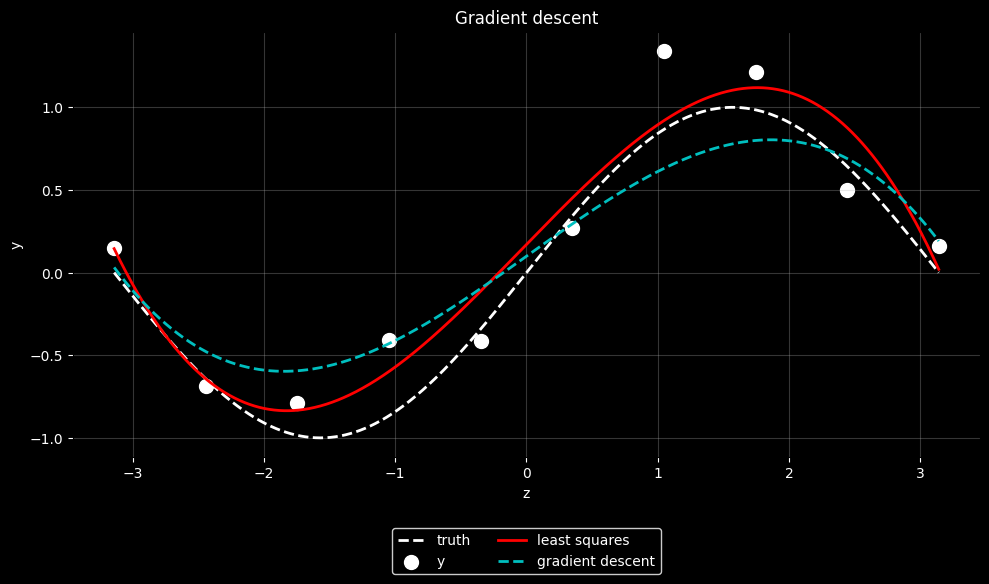

In [9]:
# Plotting the results
plt.figure(figsize=(10, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
ax.grid(True, alpha=0.3)
ax.plot(z_grid, y_grid, 'w--', linewidth=2, label=r'truth')
ax.scatter(z, y, color='white', s=100, label=r'y')
ax.plot(z_grid, y_pinv, 'r-', linewidth=2, label=r'least squares')
ax.plot(z_grid, y_gd, 'c--', linewidth=2, label=r'gradient descent')
ax.set_xlabel('z', color='white')
ax.set_ylabel('y', color='white')
ax.set_title('Gradient descent', color='white')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2,
         facecolor='black', edgecolor='white', labelcolor='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

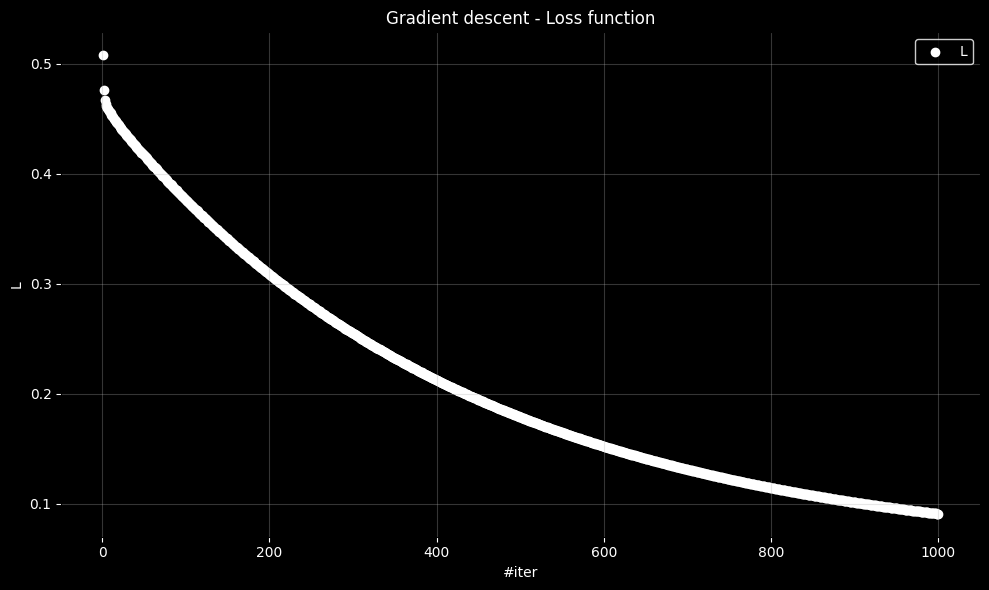

In [10]:
# Loss function iterates
plt.figure(figsize=(10, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
ax.grid(True, alpha=0.3)
ax.scatter(range(1, i_max + 1), L_all, color='white', label=r'L')
ax.set_xlabel('#iter', color='white')
ax.set_ylabel('L', color='white')
ax.set_title('Gradient descent - Loss function', color='white')
ax.legend(facecolor='black', edgecolor='white', labelcolor='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

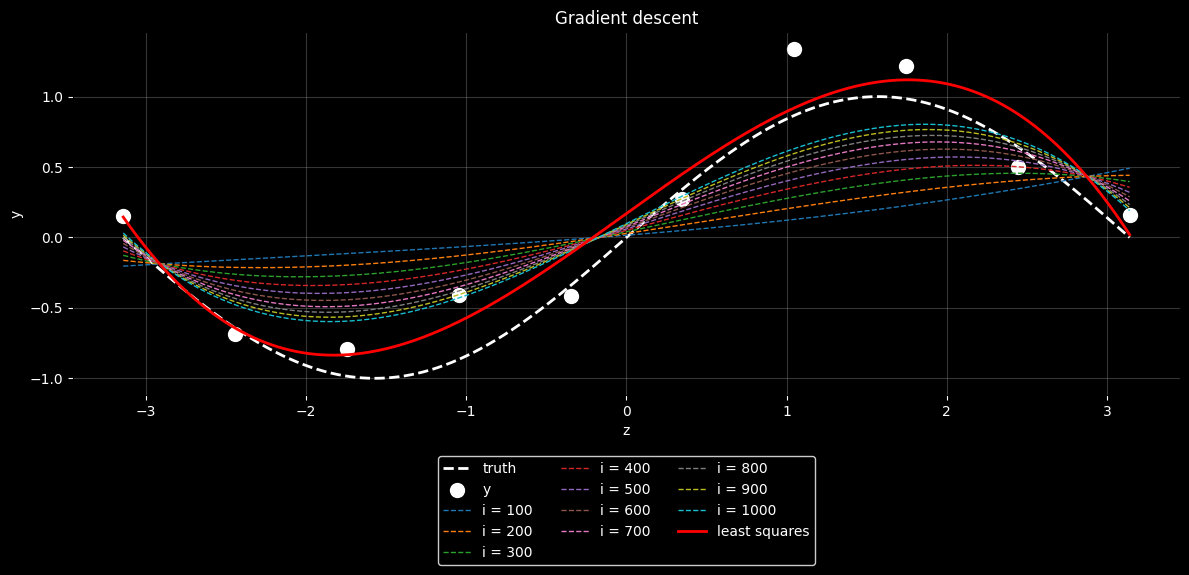

In [11]:
# Model iterates - Plotting the results
plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
ax.grid(True, alpha=0.3)
ax.plot(z_grid, y_grid, 'w--', linewidth=2, label=r'truth')
ax.scatter(z, y, color='white', s=100, label=r'y')

for i in range(99, i_max, 100):
    y_i = h(z_grid, w_all[:, i])
    ax.plot(z_grid, y_i, '--', linewidth=1, label=f'i = {i+1}')

ax.plot(z_grid, y_pinv, 'r-', linewidth=2, label=r'least squares')
ax.set_xlabel('z', color='white')
ax.set_ylabel('y', color='white')
ax.set_title('Gradient descent', color='white')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3,
         facecolor='black', edgecolor='white', labelcolor='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

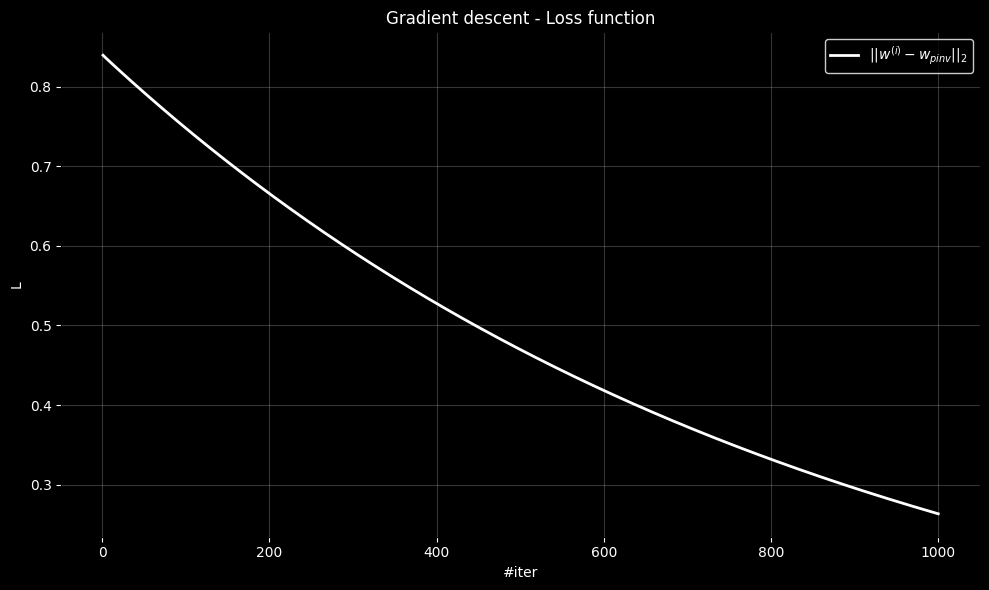

In [12]:
# Weight iterates
delta_w = np.zeros(i_max)
for i in range(i_max):
    delta_w[i] = norm(w_all[:, i] - w_pinv, 2)

plt.figure(figsize=(10, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
ax.grid(True, alpha=0.3)
ax.plot(range(1, i_max + 1), delta_w, 'w-', linewidth=2, label=r'$||w^{(i)} - w_{pinv}||_2$')
ax.set_xlabel('#iter', color='white')
ax.set_ylabel('L', color='white')
ax.set_title('Gradient descent - Loss function', color='white')
ax.legend(facecolor='black', edgecolor='white', labelcolor='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

Now let's try some additional stopping criteria, i.e.,
$$ \nabla L(w) < \epsilon_\nabla \qquad \text{or} \qquad L^{(i)} - L^{(i+1)} < \epsilon_L$$

In [13]:
# let's try once more using different stopping criteria

# thresholds for the gradient as well as the loss function improvement
eps_grad = 1e-5
eps_L = 1e-5

# initial guess
w_SC = w0.copy()

# dummy variable to compare with previous iteration
L_prev = 1e10

# for loop over (too) many iterations
for i in range(1000000):
    
    # compute gradient ...
    dL_i = dL(w_SC, Z, y)
    norm_dummy = norm(dL_i, 2)
    # ... and check whether it is small
    if norm_dummy < eps_grad:
        print(f"Stopping after {i} iterations: ||dL|| = {norm(dL_i, 2):.4e}")
        break

    # if not, update weights
    w_SC = w_SC - eta * dL_i

    # compute updated loss function
    L_i = L(w_SC, Z, y)

    # check for sufficient decrease of L
    if L_prev - L_i < eps_L:
        print(f"Stopping after {i} iterations: ||L_{{i-1}} - L_i|| = {L_prev - L_i:.4e}")
        break

print(f"\nDifference to pinv: ||w_pinv - w_SC|| = {norm(w_pinv - w_SC, 2):.4e}")

Stopping after 11204 iterations: ||dL|| = 9.9957e-06

Difference to pinv: ||w_pinv - w_SC|| = 1.1580e-05


Let's compare the performance of different learning rates

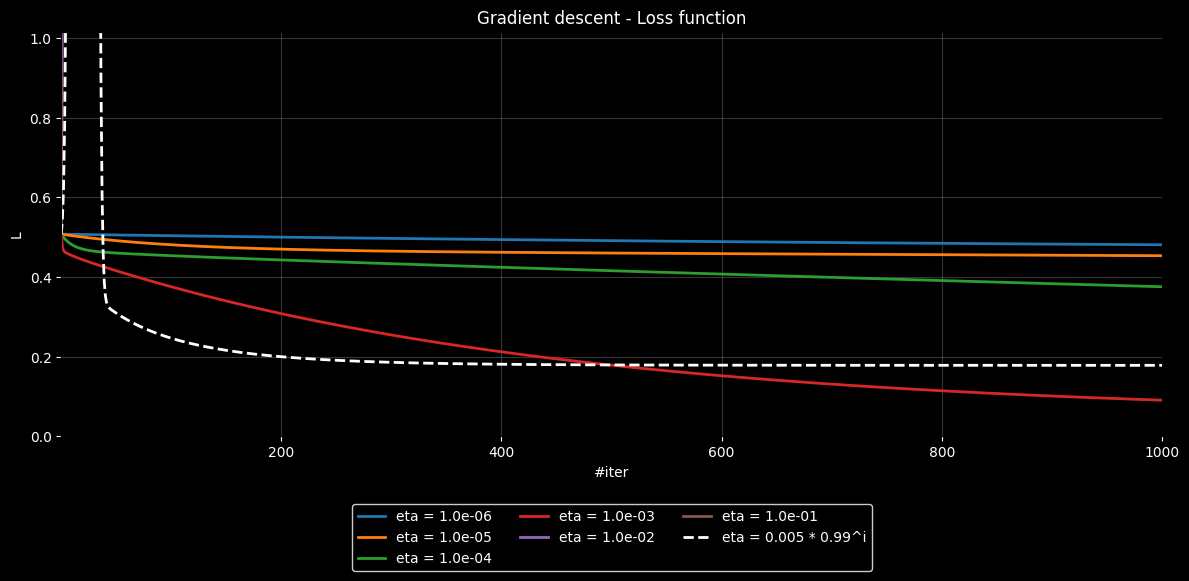

In [14]:
# compare different learning rates
# initial guess w0
w0 = np.zeros(q)

# learning rate / step size
eta_all = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

# set up empty plot
plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 1000])
ax.set_ylim([0, 2 * L(w0, Z, y)])

# train for all eta in eta_all
for eta in eta_all:
    
    w_eta = w0.copy()
    L_eta = np.zeros(1000)
    L_eta[0] = L(w_eta, Z, y)
    
    for i in range(999):
        # gradient step
        w_eta = w_eta - eta * dL(w_eta, Z, y)
        
        # store loss function value
        L_eta[i + 1] = L(w_eta, Z, y)
    
    # Add plot to scatter
    ax.plot(range(1, 1001), L_eta, linewidth=2, label=f'eta = {eta:.1e}')

# Finally, an adaptive step size
w_eta = w0.copy()
L_eta = np.zeros(1000)
L_eta[0] = L(w_eta, Z, y)

eta = 5e-3
for i in range(999):
    # gradient step
    w_eta = w_eta - eta * dL(w_eta, Z, y)
    eta *= 0.99 # decay step size by 1% every iteration
    
    # store loss function value
    L_eta[i + 1] = L(w_eta, Z, y)

# Add plot
ax.plot(range(1, 1001), L_eta, 'w--', linewidth=2, label='eta = 0.005 * 0.99^i')
    
ax.set_xlabel('#iter', color='white')
ax.set_ylabel('L', color='white')
ax.set_title('Gradient descent - Loss function', color='white')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3,
         facecolor='black', edgecolor='white', labelcolor='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

# Armijo backtracking

Starting with a step length $\eta_0$, we decrease the step size repeatedly (by multiplication with $\alpha\in(0,1)$) until a sufficient decrease is guaranteed, i.e.,
$$ L\left(w^{(i)}-\alpha^k \eta_0 \nabla L(w^{(i)})\right) \leq L(w^{(i)}) - \epsilon_{1} \left(\nabla L(w^{(i)})\right)^\top \nabla L(w^{(i)}).$$

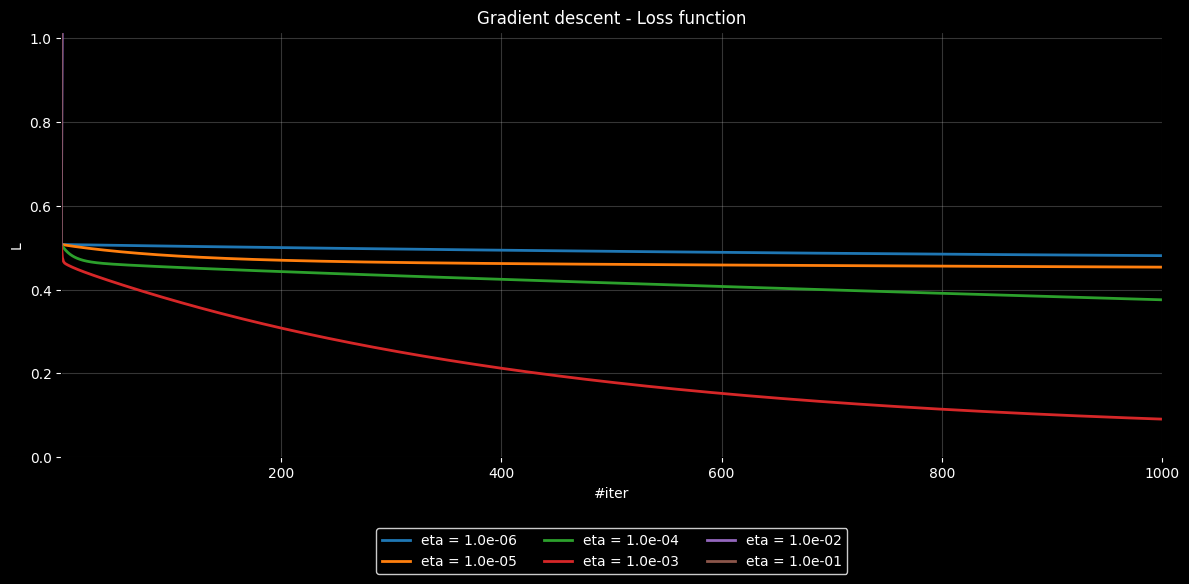

In [15]:
# compare different learning rates, same as last time
# initial guess w0
w0 = np.zeros(q)

# learning rate / step size
eta_all = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

# set up empty plot
plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 1000])
ax.set_ylim([0, 2 * L(w0, Z, y)])

# train for all eta in eta_all
for eta in eta_all:
    
    w_eta = w0.copy()
    L_eta = np.zeros(1000)
    L_eta[0] = L(w_eta, Z, y)
    
    for i in range(999):
        # gradient step
        w_eta = w_eta - eta * dL(w_eta, Z, y)
        
        # store loss function value
        L_eta[i + 1] = L(w_eta, Z, y)
    
    # Add plot
    ax.plot(range(1, 1001), L_eta, linewidth=2, label=f'eta = {eta:.1e}')

ax.set_xlabel('#iter', color='white')
ax.set_ylabel('L', color='white')
ax.set_title('Gradient descent - Loss function', color='white')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3,
         facecolor='black', edgecolor='white', labelcolor='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

1000


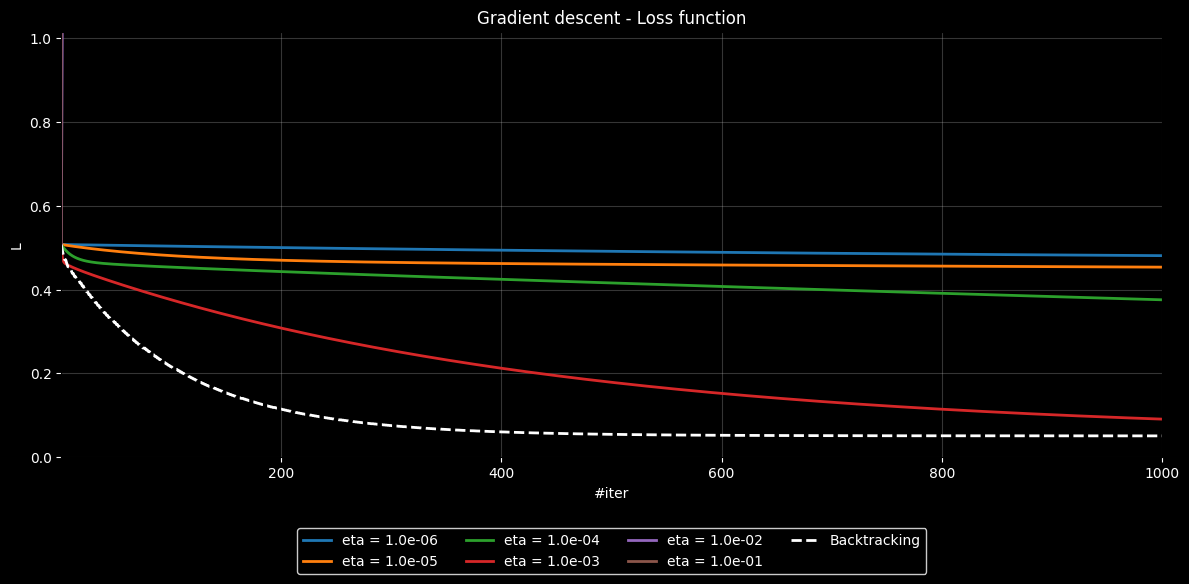

In [16]:
# And here comes the Armijo code
w_eta = w0.copy()
L_eta = np.zeros(1000)
L_eta[0] = L(w_eta, Z, y)

eta_store = np.zeros(1000)

eta0 = 1e-2
alpha = 0.9

eps_1 = 1e-4
eps_grad = 1e-6

iMax = 1000
for i in range(999):
    # evaluate gradient
    dL_i = dL(w_eta, Z, y)

    # stopping criterion for small gradient
    if norm(dL_i, 2) < eps_grad:
        print(f"Stopping after {i} iterations: ||dL|| = {norm(dL_i, 2):.4e}")
        iMax = i
        break

    # backtracking loop
    eta = eta0
    while L(w_eta - eta * dL_i, Z, y) > L_eta[i] - eps_1 * eta * np.dot(dL_i, dL_i):
        eta *= alpha

        # stop if step length gets too small
        if eta < 1e-6:
            iMax = i
            break

    # stop the entire routine if the step length is too small
    if eta < 1e-6:
        iMax = i
        break

    # gradient step
    w_eta = w_eta - eta * dL_i

    # store current eta value
    eta_store[i] = eta

    # store loss function value
    L_eta[i + 1] = L(w_eta, Z, y)

print(iMax)

# Plotting
plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 1000])
ax.set_ylim([0, 2 * L(w0, Z, y)])

# Plot all learning rates again
for eta in eta_all:
    w_eta_temp = w0.copy()
    L_eta_temp = np.zeros(1000)
    L_eta_temp[0] = L(w_eta_temp, Z, y)
    for i in range(999):
        w_eta_temp = w_eta_temp - eta * dL(w_eta_temp, Z, y)
        L_eta_temp[i + 1] = L(w_eta_temp, Z, y)
    ax.plot(range(1, 1001), L_eta_temp, linewidth=2, label=f'eta = {eta:.1e}')

# Add backtracking plot
ax.plot(range(1, iMax + 1), L_eta[:iMax], 'w--', linewidth=2, label='Backtracking')

ax.set_xlabel('#iter', color='white')
ax.set_ylabel('L', color='white')
ax.set_title('Gradient descent - Loss function', color='white')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4,
         facecolor='black', edgecolor='white', labelcolor='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

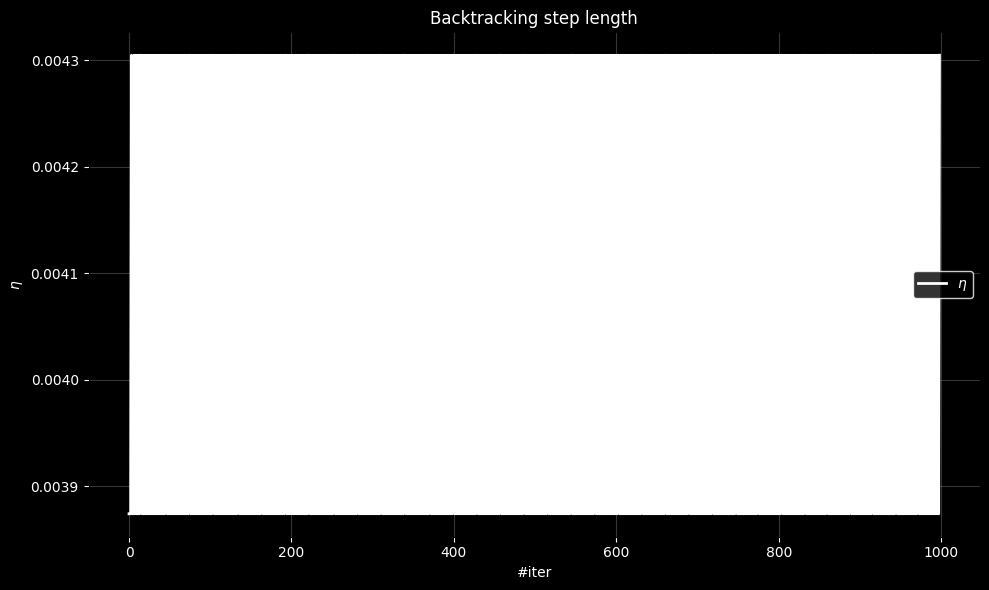

In [17]:
# visualize the step length
plt.figure(figsize=(10, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
ax.grid(True, alpha=0.3)
ax.plot(eta_store[:iMax-1], color='white', linewidth=2, label=r'$\eta$')
ax.set_xlabel('#iter', color='white')
ax.set_ylabel(r'$\eta$', color='white')
ax.set_title('Backtracking step length', color='white')
ax.legend(facecolor='black', edgecolor='white', labelcolor='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

# Stochastic gradient descent

To reduce the cost of a particular gradient evaluation, we can compute the gradient using only a subset of the samples $\{z_i,y_i\}$

In [18]:
# Stochastic loss function and gradient
def stochastic_L(w, Z, y, s=1):
    """
    Compute stochastic loss and gradient using batch size s
    """
    N = len(y)
    indices = np.random.choice(N, s, replace=False) #sampling a subset of the data points without replacement
    
    L_stoch = (1/s) * norm(y[indices] - Z[indices, :] @ w, 2) ** 2 #Not Averaging over all data points, but only over the sampled ones
    dL_stoch = (2/s) * Z[indices, :].T @ (Z[indices, :] @ w - y[indices])
    
    return L_stoch, dL_stoch

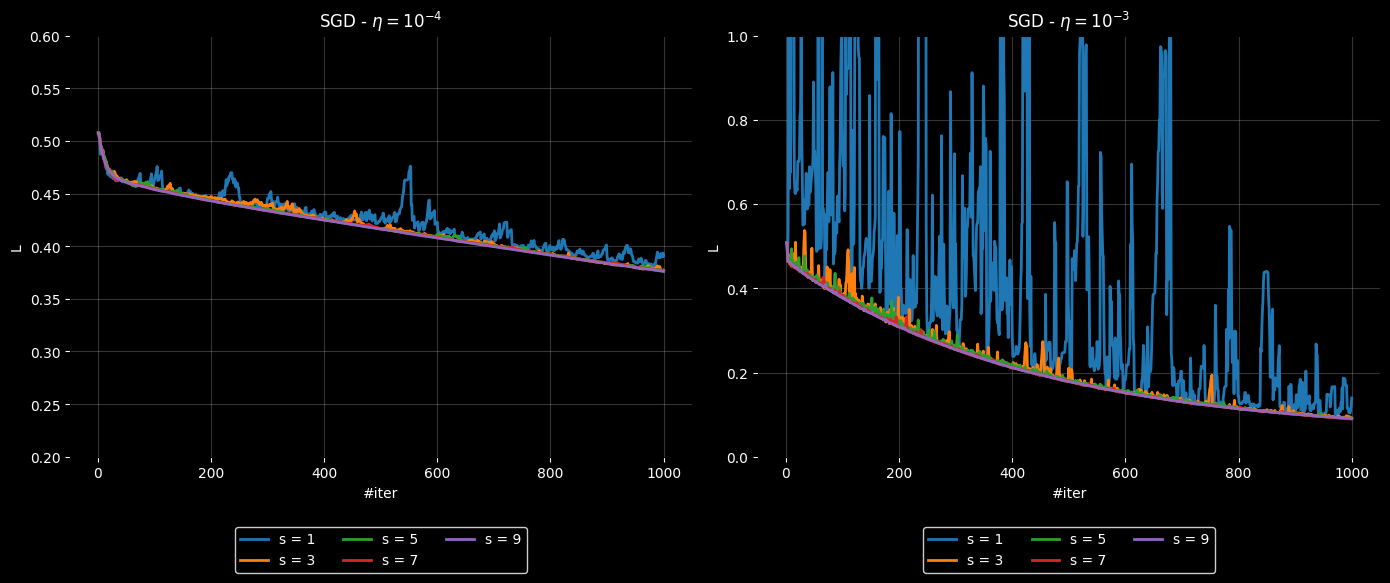

In [19]:
# compare different batch sizes and learning rates
# initial guess w0
q = 4
w0 = np.zeros(q)

# set up two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor='black')

for ax in [ax1, ax2]:
    ax.set_facecolor('black')
    ax.grid(True, alpha=0.3)
    ax.tick_params(colors='white')

# batch size
s_all = [1, 3, 5, 7, 9] #different batch sizes, s = 1 corresponds to pure SGD, s = N corresponds to full batch GD

# learning rate / step size
eta_all = [1e-4, 1e-3] #different learning rates, we will plot the results for eta = 1e-4 in the left subplot and for eta = 1e-3 in the right subplot

# train for all eta in eta_all
for eta_idx, eta in enumerate(eta_all):
    
    ax = ax1 if eta == 1e-4 else ax2
    ax.set_title(f'SGD - $\\eta=10^{{{int(np.log10(eta))}}}$', color='white')
    ax.set_xlabel('#iter', color='white')
    ax.set_ylabel('L', color='white')
    
    if eta == 1e-4:
        ax.set_ylim([0.2, 0.6])
    else:
        ax.set_ylim([0, 1])
    
    for s in s_all:
        w_SGD = np.zeros((q, 1000))
        w_SGD[:, 0] = w0
        L_SGD = np.zeros(1000)
        L_SGD[0] = L(w0, Z, y)
        
        for i in range(999):
            # evaluate loss function and stochastic gradient
            L_i, dL_i = stochastic_L(w_SGD[:, i], Z, y, s)
            
            # gradient step
            w_SGD[:, i + 1] = w_SGD[:, i] - eta * dL_i
            
            # store loss function value
            L_SGD[i + 1] = L(w_SGD[:, i], Z, y)
        
        # Add plot
        ax.plot(range(1, 1001), L_SGD, linewidth=2, label=f's = {s}')
    
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3,
             facecolor='black', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

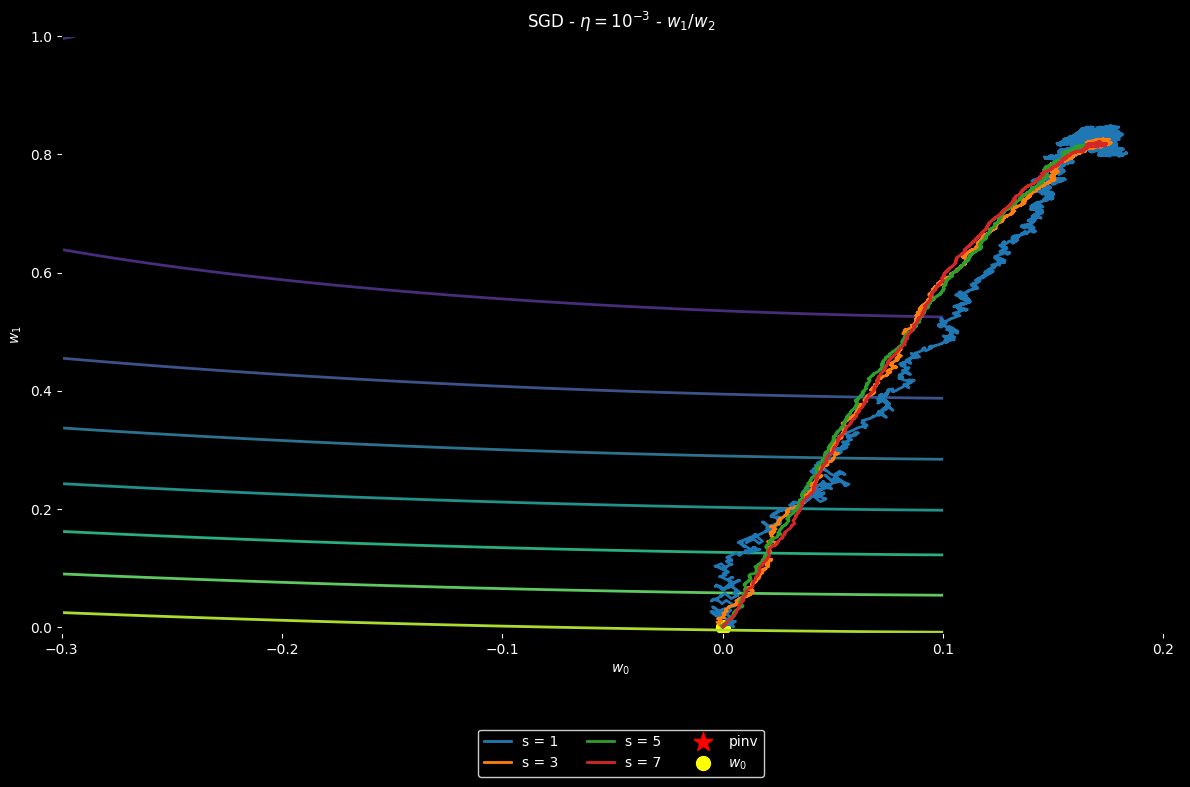

In [21]:
# For comparison, let's create a grid of w values to show level sets of L(w)
w_grid1 = np.linspace(-0.3, 0.1, 1000)
w_grid2 = np.linspace(-0.01, 1.0, 1000)
L_grid = np.zeros((1000, 1000))

for i in range(1000):
    for j in range(1000):
        L_grid[i, j] = L(np.array([w_grid1[j], w_grid2[i], w_pinv[2], w_pinv[3]]), Z, y)

# compare different batch sizes
# initial guess w0
q = 4
w0 = np.zeros(q)

# set up empty plot
plt.figure(figsize=(12, 8), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
ax.contour(w_grid1, w_grid2, L_grid, cmap='viridis', linewidths=2)
ax.tick_params(colors='white')

# batch size
s_all = [1, 3, 5, 7]

# learning rate / step size
eta_all = [1e-3]

# train for all eta in eta_all
for eta in eta_all:
    for s in s_all:
        w_SGD = np.zeros((q, 10000))
        w_SGD[:, 0] = w0
        L_SGD = np.zeros(10000)
        L_SGD[0] = L(w0, Z, y)
        
        for i in range(9999):
            # evaluate loss function and stochastic gradient
            L_i, dL_i = stochastic_L(w_SGD[:, i], Z, y, s)
            
            # gradient step
            w_SGD[:, i + 1] = w_SGD[:, i] - eta * dL_i
            
            # store loss function value
            L_SGD[i + 1] = L(w_SGD[:, i], Z, y)
        
        # Add plot
        ax.plot(w_SGD[0, :], w_SGD[1, :], linewidth=2, label=f's = {s}')

ax.scatter([w_pinv[0]], [w_pinv[1]], c='red', s=200, marker='*', label='pinv')
ax.scatter([w0[0]], [w0[1]], c='yellow', s=100, label='$w_0$')
ax.set_xlabel('$w_0$', color='white')
ax.set_ylabel('$w_1$', color='white')
ax.set_title('SGD - $\\eta=10^{-3}$ - $w_1 / w_2$', color='white')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3,
         facecolor='black', edgecolor='white', labelcolor='white')
plt.tight_layout()
plt.show()